In [30]:
# Basic setup cell.
#Just import everything from Workshops;
#later imports during Debugging.
#used seed here to keep repeating the same result..
import os, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    ConfusionMatrixDisplay, multilabel_confusion_matrix,
    roc_curve, auc, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



In [31]:
#Load the train and test data
#header=None is needed because the CSV files do not have column names.
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df  = pd.read_csv('mitbih_test.csv',  header=None)

print(f'Train shape: {train_df.shape}')   # 87554 rows, 188 cols (187 features + 1 label)
print(f'Test  shape: {test_df.shape}')    # 21892 rows
train_df.head()

Train shape: (87554, 188)
Test  shape: (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
""" Data Analysis:
-make sure they're imported correctly and check the sahpes: #print("Training set shape:", train_df.shape) print("Testing set shape:", test_df.shape)
-Check first few rows of data; to see what it looks like, to see the balance: #print(train_df.head())
-check last column is it 4 or 5 ? #print(train_df.iloc[:, -1].unique())
-check how many samples there are per class? #print(train_df.iloc[:,-1].value_counts().sort_index())
--------
Very important things we can notice from the dataset:
-- our data is 1D numerical time-series ECG heartbeat signal data --
1 all values are between 0 - 1.
2 last column is 4 , lables are from 0 to 4 so no need for label encoding.
3 very very big imbalance in train classes!!?
Class 3 (Type2) only 641 sample comparing to 72,471 in class 0 !
That could cause in making the model lazy so we must create more samples for type 3 to train the model on.
***Report material*** """


' Data Analysis: \n-make sure they\'re imported correctly and check the sahpes: #print("Training set shape:", train_df.shape) print("Testing set shape:", test_df.shape)\n-Check first few rows of data; to see what it looks like, to see the balance: #print(train_df.head())\n-check last column is it 4 or 5 ? #print(train_df.iloc[:, -1].unique())\n-check how many samples there are per class? #print(train_df.iloc[:,-1].value_counts().sort_index())\n--------\nVery important things we can notice from the dataset:\n-- our data is 1D numerical time-series ECG heartbeat signal data --\n1 all values are between 0 - 1.\n2 last column is 4 , lables are from 0 to 4 so no need for label encoding.\n3 very very big imbalance in train classes!!?\nClass 3 (Type2) only 641 sample comparing to 72,471 in class 0 !\nThat could cause in making the model lazy so we must create more samples for type 3 to train the model on.\n***Report material*** '

Class distribution — Training set:
  Class 0 (        Normal):  72471  (82.8%)
  Class 1 (Hypersensitive):   2223  (2.5%)
  Class 2 (        Type 1):   5788  (6.6%)
  Class 3 (        Type 2):    641  (0.7%)
  Class 4 (        Type 3):   6431  (7.3%)


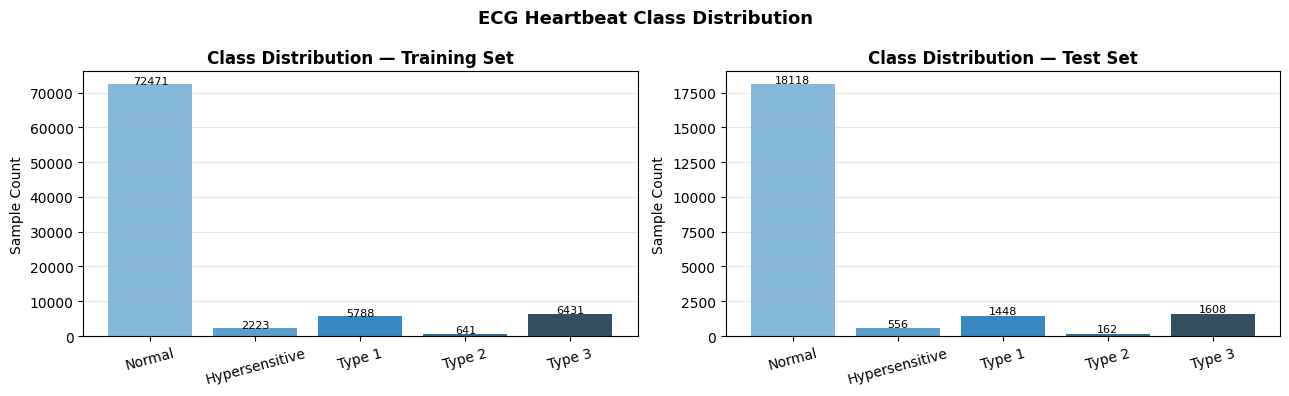

' Visualising the data: ( More understanding ) , included Percentage values for report '

In [33]:
# Check the class distribution.
# This is important because the dataset is highly imbalanced.
class_names  = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']
class_counts = train_df.iloc[:, -1].value_counts().sort_index()

print('Class distribution — Training set:')
for i, (count, name) in enumerate(zip(class_counts.values, class_names)):
    print(f'  Class {i} ({name:>14}): {count:>6}  ({count/len(train_df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, title in zip(axes, [train_df, test_df], ['Training Set', 'Test Set']):
    counts = df.iloc[:, -1].value_counts().sort_index()
    bars   = ax.bar(class_names, counts.values, color=sns.color_palette('Blues_d', 5))
    ax.set_title(f'Class Distribution — {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Sample Count')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                str(v), ha='center', fontsize=8)
plt.suptitle('ECG Heartbeat Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

""" Visualising the data: ( More understanding ) , included Percentage values for report """

In [34]:
# Check for missing values.
# If this prints zero, no imputation or row deletion is needed.
train_missing = train_df.isnull().sum().sum()
test_missing  = test_df.isnull().sum().sum()
print(f'Missing values — Train: {train_missing}')
print(f'Missing values — Test : {test_missing}')

if train_missing == 0 and test_missing == 0:
    print('Dataset is clean — no imputation required.')
else:
    for df in [train_df, test_df]:
        for cls in df.iloc[:, -1].unique():
            mask = df.iloc[:, -1] == cls
            df.loc[mask] = df.loc[mask].fillna(df.loc[mask].mean())
    print('Per-class mean imputation applied.')
    #Result is 0, >>> Clean Data.


Missing values — Train: 0
Missing values — Test : 0
Dataset is clean — no imputation required.


In [35]:
# Data preprocessing: split features and labels.
#split the data into x and y to do hot encoding to lables only.
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values
X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values

#All col. except the last and the last col#. only.
#first 187 are signals but the last one is label.
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'Labels: {sorted(np.unique(y_train.astype(int)))}')  # should be [0,1,2,3,4]

X_train: (87554, 187)  y_train: (87554,)
X_test:  (21892, 187)   y_test:  (21892,)
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [36]:
#One-hot encode the labels.
#Converting lables to int. first then encode.
y_train_encoded = to_categorical(y_train.astype(int), num_classes=5)
y_test_encoded  = to_categorical(y_test.astype(int),  num_classes=5)
print(f'y_train_encoded: {y_train_encoded.shape}')
print(f'y_test_encoded:  {y_test_encoded.shape}')

y_train_encoded: (87554, 5)
y_test_encoded:  (21892, 5)


In [37]:
#Normalisation of data:
# This avoids using test-set information during training.
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit on train only
X_test_scaled  = scaler.transform(X_test) # transform test only
print(f'Train — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}')
print(f'Test  — mean: {X_test_scaled.mean():.4f},  std: {X_test_scaled.std():.4f}')

Train — mean: -0.0000, std: 1.0000
Test  — mean: -0.0048,  std: 0.9946


In [38]:
# Reshape the data for Conv1D.
# Before: (samples, 187).
# After:  (samples, 187, 1), #adding the channels as CNN requires.
X_train_cnn = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(-1,  X_test_scaled.shape[1],  1)
print(f'X_train_cnn: {X_train_cnn.shape}')
print(f'X_test_cnn:  {X_test_cnn.shape}')

X_train_cnn: (87554, 187, 1)
X_test_cnn:  (21892, 187, 1)


In [39]:
#compute class weights to handle class imbalance.
# Rare classes get higher weights, mistakes on them cost more .
classes           = np.unique(y_train.astype(int))
weights           = compute_class_weight('balanced', classes=classes, y=y_train.astype(int))
class_weight_dict = dict(zip(classes, weights))

print('Class weights:')
for cls, w in class_weight_dict.items():
    print(f'  Class {cls} ({class_names[cls]:>14}): {w:.4f}')



Class weights:
  Class 0 (        Normal): 0.2416
  Class 1 (Hypersensitive): 7.8771
  Class 2 (        Type 1): 3.0254
  Class 3 (        Type 2): 27.3179
  Class 4 (        Type 3): 2.7229


In [40]:
#shuffle the training data before validation
# The dataset appears ordered by class, so shuffling makes the validation split representative.
X_train_s, y_train_s = shuffle(X_train_cnn, y_train_encoded, random_state=SEED)
print(f'X_train_s: {X_train_s.shape}')
print('Preprocessing complete.')

X_train_s: (87554, 187, 1)
Preprocessing complete.


In [41]:
"""Development attempts kept for reference::::::
I kept the failed attempts below as commented reference code,
not as part of the final pipeline.They explain what I tried before the final model
and why the final setup was chosen,
The final model starts after these notes,
Using shuffling, class weights, learning rate 0.0001 and batch size 32. """

'Development attempts kept for reference::::::\nI kept the failed attempts below as commented reference code,\nnot as part of the final pipeline.They explain what I tried before the final model \nand why the final setup was chosen,\nThe final model starts after these notes,\nUsing shuffling, class weights, learning rate 0.0001 and batch size 32. '

In [42]:
"""
# ATTEMPT 1 — FAILED BASELINE CNN (DO NOT RUN)
#kept this code commented out of the first failed development step.
#
#what I tried:::
-A simple 1D CNN.
- Adam with learning rate 0.001.
- batch size 64.
 No class weights.
  No manual shuffle before validation_split.
----
# What happened:
=Training accuracy reached almost 100%.
=Validation accuracy was only about 13.87%.
=Training loss was almost 0, but validation loss went to about 42.26.
---
# What I learned:
#High training accuracy alone is not useful.
# model memorised the training data but did not generalise.
# dataset is severely imbalanced, so the model focus too much on Normal.
-the data appeared ordered by class, so validation_split without shuffling was bad
'''''''''''''''''''
 model_attempt1 = Sequential([
     Conv1D(32, kernel_size=5, activation='relu', input_shape=(187, 1)),
     BatchNormalization(),
     MaxPooling1D(pool_size=2),
     Dropout(0.3),

     Conv1D(64, kernel_size=3, activation='relu'),
     BatchNormalization(),
     MaxPooling1D(pool_size=2),
     Dropout(0.3),

     Flatten(),
     Dense(64, activation='relu'),
     Dropout(0.4),
     Dense(5, activation='softmax')
 ])

 model_attempt1.compile(
     optimizer=Adam(learning_rate=0.001),
     loss='categorical_crossentropy',
     metrics=['accuracy']
 )

 history_attempt1 = model_attempt1.fit(
     X_train_cnn,
     y_train_encoded,
     epochs=30,
     batch_size=64,
     validation_split=0.2,
     callbacks=[early_stopping, checkpoint]
 )
''''''''''''''
# Result kept for the report:
# Train accuracy ≈ 100%, validation accuracy ≈ 13.87% >>>failed generalisation.
"""

"\n# ATTEMPT 1 — FAILED BASELINE CNN (DO NOT RUN) \n#kept this code commented out of the first failed development step.\n#\n#what I tried:::\n-A simple 1D CNN.\n- Adam with learning rate 0.001.\n- batch size 64.\n No class weights.\n  No manual shuffle before validation_split.\n----\n# What happened:\n=Training accuracy reached almost 100%.\n=Validation accuracy was only about 13.87%.\n=Training loss was almost 0, but validation loss went to about 42.26.\n---\n# What I learned:\n#High training accuracy alone is not useful.\n# model memorised the training data but did not generalise.\n# dataset is severely imbalanced, so the model focus too much on Normal.\n-the data appeared ordered by class, so validation_split without shuffling was bad\n'''''''''''''''''''\n model_attempt1 = Sequential([\n     Conv1D(32, kernel_size=5, activation='relu', input_shape=(187, 1)),\n     BatchNormalization(),\n     MaxPooling1D(pool_size=2),\n     Dropout(0.3),\n\n     Conv1D(64, kernel_size=3, activation

In [43]:
""" ── ATTEMPT 2 — FAILED CORRECTION (DO NOT RUN)
the second failed development setup.
 added class_weight, which was good, but I also changed other things
something was wrong in a way that made training unstable.

# What I tried:
class weights to handle class imbalance.
learning rate 0.001.
batch size 64.
-Removed the manual shuffle step before validation_split.

# What went wrong:
 classweight alone is not enough.
Because the dataset is ordered by class, validation_split could still take an unrepresentative final part of the data.
*Learning rate 0.001 was too aggressive with large class weights.
*Rare-class errors had large loss penalties, so the gradient updates became unstable.
#
# What I learned:
= needed BOTH class_weight and shuffling.
= also needed a lower learning rate and smaller batch size.
= This led to the final setup: shuffle + class_weight + lr=0.0001 + batch_size=32.
@@@@@@@@
 model_attempt2 = Sequential([
     Conv1D(32, kernel_size=5, activation='relu', input_shape=(187, 1)),
     BatchNormalization(),
     MaxPooling1D(pool_size=2),
     Dropout(0.3),

     Conv1D(64, kernel_size=3, activation='relu'),
     BatchNormalization(),
     MaxPooling1D(pool_size=2),
     Dropout(0.3),

     Flatten(),
     Dense(64, activation='relu'),
     Dropout(0.4),
     Dense(5, activation='softmax')
 ])

 model_attempt2.compile(
     optimizer=Adam(learning_rate=0.001),
     loss='categorical_crossentropy',
     metrics=['accuracy']
 )

 history_attempt2 = model_attempt2.fit(
     X_train_cnn,              # unshuffled data used here in the failed setup
     y_train_encoded,
     epochs=30,
     batch_size=64,
     validation_split=0.2,
     class_weight=class_weight_dict,
     callbacks=[early_stopping, checkpoint]
 )

# Result kept for the report:
# Validation behaviour was still unstable/collapsed, so this setup was rejected.
"""


" ── ATTEMPT 2 — FAILED CORRECTION (DO NOT RUN)\nthe second failed development setup.\n added class_weight, which was good, but I also changed other things\nsomething was wrong in a way that made training unstable.\n\n# What I tried:\nclass weights to handle class imbalance.\nlearning rate 0.001.\nbatch size 64.\n-Removed the manual shuffle step before validation_split.\n\n# What went wrong:\n classweight alone is not enough.\nBecause the dataset is ordered by class, validation_split could still take an unrepresentative final part of the data.\n*Learning rate 0.001 was too aggressive with large class weights.\n*Rare-class errors had large loss penalties, so the gradient updates became unstable.\n#\n# What I learned:\n= needed BOTH class_weight and shuffling.\n= also needed a lower learning rate and smaller batch size.\n= This led to the final setup: shuffle + class_weight + lr=0.0001 + batch_size=32.\n@@@@@@@@\n model_attempt2 = Sequential([\n     Conv1D(32, kernel_size=5, activation='

In [44]:
"""
SMOTE experiment kept for reference only
I also tried SMOTE during development because the minority classes,especially Type 2, had low precision.
 The idea was to create synthetic minority-class samples so the CNN could see more rare examples.

I did not keep SMOTE in the final model. When reviewing the experiment,
I found that the tuning/evaluation process risked using test-set information while choosing model settings,
 which would make the high accuracy unreliable. For the final submission I used the cleaner class-weighted CNN instead.
 *****REPORT*******
 """

'\nSMOTE experiment kept for reference only\nI also tried SMOTE during development because the minority classes,especially Type 2, had low precision.\n The idea was to create synthetic minority-class samples so the CNN could see more rare examples.\n\nI did not keep SMOTE in the final model. When reviewing the experiment, \nI found that the tuning/evaluation process risked using test-set information while choosing model settings,\n which would make the high accuracy unreliable. For the final submission I used the cleaner class-weighted CNN instead.\n *****REPORT*******\n '

In [45]:
"""#  SMOTE EXPERIMENT — REJECTED / Just for knowledge
# The final submitted model does NOT use SMOTE.

# Why I tried it:
Type 2 was only about 0.7% of the training set.
Class weights gave high recall but low precision for rare classes.
SMOTE looked like a possible way to create more minority-class examples.

from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping

 # Convert one-hot labels back to class labels for SMOTE.
y_train_labels = np.argmax(y_train_encoded, axis=1)

#  SMOTE works on 2D feature matrices, so use the scaled tabular shape first.
# # IMPORTANT: this should only ever be applied to the training data.
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_labels)

# # Reshape back for Conv1D after SMOTE.
 X_train_smote_cnn = X_train_smote.reshape(X_train_smote.shape[0], 187, 1)
 y_train_smote_encoded = to_categorical(y_train_smote, num_classes=5)

 # Example SMOTE model training attempt.
smote_model = build_model(dropout_rate=0.3, learning_rate=0.0001)
smote_history = smote_model.fit(
    X_train_smote_cnn,
    y_train_smote_encoded,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

#What went wrong in the rejected experiment:
during one version of tuning, I evaluated candidate settings on the test set.
caused data leakage because the test set should only be used once at the end.
# # Example of the rejected idea:
# # loss, acc = smote_model.evaluate(X_test_cnn, y_test_encoded, verbose=0)

# # Because of this risk, I deleted SMOTE from the final pipeline and used class_weight instead.
**** REPORT MATERIAL****
"""


'#  SMOTE EXPERIMENT — REJECTED / Just for knowledge \n# The final submitted model does NOT use SMOTE.\n\n# Why I tried it:\nType 2 was only about 0.7% of the training set.\nClass weights gave high recall but low precision for rare classes.\nSMOTE looked like a possible way to create more minority-class examples.\n\nfrom imblearn.over_sampling import SMOTE\nfrom tensorflow.keras.callbacks import EarlyStopping\n\n # Convert one-hot labels back to class labels for SMOTE.\ny_train_labels = np.argmax(y_train_encoded, axis=1)\n\n#  SMOTE works on 2D feature matrices, so use the scaled tabular shape first.\n# # IMPORTANT: this should only ever be applied to the training data.\nsmote = SMOTE(random_state=SEED)\nX_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_labels)\n\n# # Reshape back for Conv1D after SMOTE.\n X_train_smote_cnn = X_train_smote.reshape(X_train_smote.shape[0], 187, 1)\n y_train_smote_encoded = to_categorical(y_train_smote, num_classes=5)\n\n # Example

In [46]:
#Build the CNN model.
#used this function several times: baseline training, grid search, k-fold CV, and final training.
# Changing dropout and learning rate here makes tuning easier.
def build_model(dropout=0.3, lr=0.0001):
    m = Sequential([
            #First Block
        Conv1D(32,  kernel_size=5, activation='relu', input_shape=(187, 1)),
        BatchNormalization(), MaxPooling1D(2), Dropout(dropout),
            # Second Block
        Conv1D(64,  kernel_size=3, activation='relu'),
        BatchNormalization(), MaxPooling1D(2), Dropout(dropout),
    #Third Block
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(), MaxPooling1D(2), Dropout(dropout),
    # Fully Layers
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout + 0.1),
        Dense(5, activation='softmax')
    ], name='ECG_1D_CNN')

    m.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m
#For clarity ::
# Print architecture summary
build_model().summary()

Model: "ECG_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 89, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 89, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 42, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 42, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       344,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 376,837 (1.44 MB)

 Trainable params: 376,389 (1.44 MB)

 Non-trainable params: 448 (1.75 KB)

In [47]:
"""
-----FOR REPORT----
Data enters as (187, 1) — one heartbeat signal
Three convolutional blocks progressively extract patterns: 32 >>> 64 → 128 filters
After flattening you get 2560 values summarising the whole signal
Two dense layers make sense of those values
Final layer outputs 5 probabilities — one per heartbeat class
Total of 376,837 parameters to learn — a solid sized model
what are we using then ?
CNN instead of MLP — ECG is a 1D time-series signal, CNN is more appropriate
StratifiedKFold instead of KFold — dataset is heavily imbalanced, stratification keeps class proportions in each fold
# learned later:class_weight — same reason, forces model to learn minority classes
# learned later : Shuffle before split — data is ordered by class, shuffling ensures validation set is representative

why??
Adam — the most popular optimiser, implements gradient descent intelligently. Directly from your Lecture 3 which showed gradient descent as the training method
Categorical Cross-Entropy — the standard loss function for multiclass classification. This is the classification equivalent of the least squares loss your lecturer showed
Accuracy — simple metric to monitor during training

"""

'\n-----FOR REPORT----\nData enters as (187, 1) — one heartbeat signal\nThree convolutional blocks progressively extract patterns: 32 >>> 64 → 128 filters\nAfter flattening you get 2560 values summarising the whole signal\nTwo dense layers make sense of those values\nFinal layer outputs 5 probabilities — one per heartbeat class\nTotal of 376,837 parameters to learn — a solid sized model\nwhat are we using then ? \nCNN instead of MLP — ECG is a 1D time-series signal, CNN is more appropriate\nStratifiedKFold instead of KFold — dataset is heavily imbalanced, stratification keeps class proportions in each fold\n# learned later:class_weight — same reason, forces model to learn minority classes\n# learned later : Shuffle before split — data is ordered by class, shuffling ensures validation set is representative\n\nwhy??\nAdam — the most popular optimiser, implements gradient descent intelligently. Directly from your Lecture 3 which showed gradient descent as the training method\nCategorical 

In [48]:
# Baseline training run.
# This uses the corrected setup: shuffling + class weights + lower learning rate.
# I use it to check that the model learns before doing grid search.
es_base = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
mc_base = ModelCheckpoint('baseline.keras', monitor='val_loss', save_best_only=True, verbose=1)

baseline_model   = build_model()
baseline_history = baseline_model.fit(
    X_train_s, y_train_s,
    epochs=30, batch_size=32,
    validation_split=0.2,
    callbacks=[es_base, mc_base],
    class_weight=class_weight_dict,
    verbose=1
)
print('Baseline training complete.')
#1- stop training the model if there's no improving
#2- avoid overfitting
#3- save best version of the model automatically

Epoch 1/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4410 - loss: 1.4314
Epoch 1: val_loss improved from None to 2.11968, saving model to baseline.keras

Epoch 1: finished saving model to baseline.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.5300 - loss: 1.0667 - val_accuracy: 0.3019 - val_loss: 2.1197
Epoch 2/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6515 - loss: 0.7195
Epoch 2: val_loss improved from 2.11968 to 1.97416, saving model to baseline.keras

Epoch 2: finished saving model to baseline.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6687 - loss: 0.6795 - val_accuracy: 0.3593 - val_loss: 1.9742
Epoch 3/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7125 - loss: 0.6013
Epoch 3: val_loss improved from 1.97416 to 1.71075, saving model to baseline.keras

Epoch 3: finished saving model to baseline.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.7278 - loss: 0.5644 - val_accuracy: 0.4421

In [49]:
"""
---REPORT----
Training will go through up to 30 epochs
Each epoch processes all 87,554 training samples
You'll see loss and accuracy printed each epoch
It will stop early if it stops improving
"""
"""
After training the first time i can notice 100% accuracy in training , 13,87 Validation
loss is close to 0 in training and validation 42.26
this is extreme overfitting , model just memorised the training data but learned nothing useful
validation of 13.87 is worse than random guessing.
The proplem? Class Imbalance: Normal heartbeats:82.8%
                                Type 2 heartbeats: 0.7%
model just learned to predict "NORMAL" for almost everything
THE FIX? >> CLASS WEIGHTS AND shuffling the data.
CHECKING FOR CLASS WEIGHTS>> """

'\nAfter training the first time i can notice 100% accuracy in training , 13,87 Validation\nloss is close to 0 in training and validation 42.26\nthis is extreme overfitting , model just memorised the training data but learned nothing useful\nvalidation of 13.87 is worse than random guessing.\nThe proplem? Class Imbalance: Normal heartbeats:82.8%\n                                Type 2 heartbeats: 0.7%\nmodel just learned to predict "NORMAL" for almost everything\nTHE FIX? >> CLASS WEIGHTS AND shuffling the data.\nCHECKING FOR CLASS WEIGHTS>> '

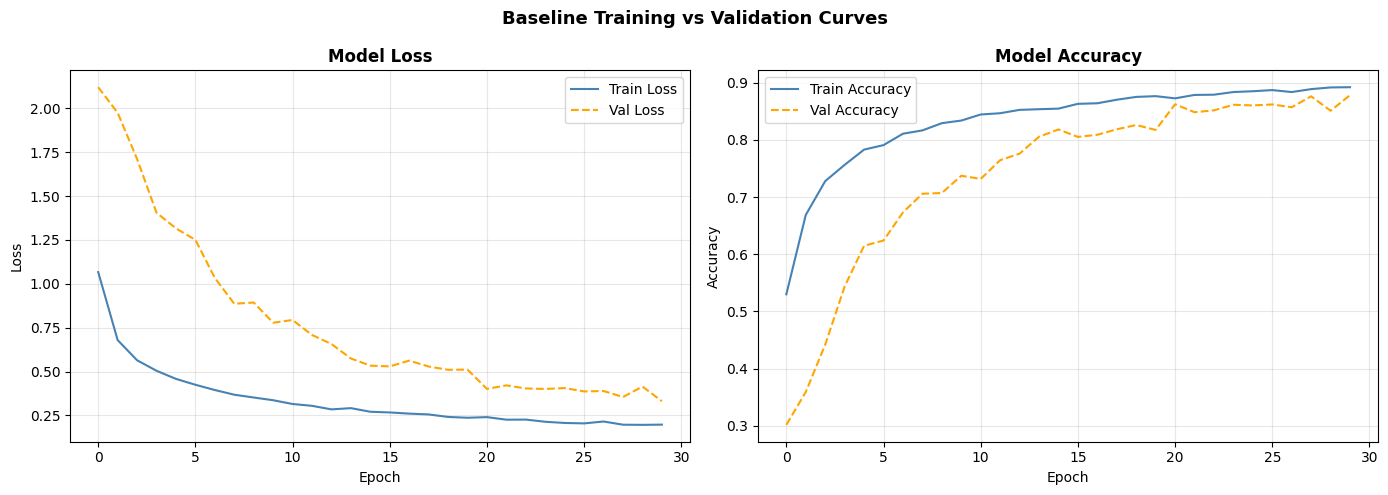

Baseline curves saved.


In [50]:
# Plot baseline training curves.
# These curves help show whether the model is learning, overfitting, or underfitting.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(baseline_history.history['loss'],     label='Train Loss',     color='steelblue')
ax1.plot(baseline_history.history['val_loss'], label='Val Loss',       color='orange', linestyle='--')
ax1.set_title('Model Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(baseline_history.history['accuracy'],     label='Train Accuracy', color='steelblue')
ax2.plot(baseline_history.history['val_accuracy'], label='Val Accuracy',   color='orange', linestyle='--')
ax2.set_title('Model Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Baseline Training vs Validation Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Baseline curves saved.')

In [51]:
"""
The baseline model shows consistent learning across 30 epochs.
Training loss decreases smoothly while validation loss follows a similar trend with higher variance,
attributable to the class imbalance in the validation split.
 The ~7% gap between train and validation accuracy indicates mild overfitting,
   which will be addressed through hyperparameter tuning."""

' \nThe baseline model shows consistent learning across 30 epochs. \nTraining loss decreases smoothly while validation loss follows a similar trend with higher variance, \nattributable to the class imbalance in the validation split.\n The ~7% gap between train and validation accuracy indicates mild overfitting,\n   which will be addressed through hyperparameter tuning.'

In [52]:
# Hyperparameter tuning using a small manual grid search.
# I tune dropout, learning rate, and batch size because these affect stability and overfitting.
# The test set is not used here to avoid data leakage.
param_grid = {
    'dropout':    [0.3, 0.5],
    'lr':         [0.0001, 0.00005],
    'batch_size': [32]
}

best_score  = 0
best_config = {}
grid_results = []

print('Starting Grid Search...')
for dropout in param_grid['dropout']:
    for lr in param_grid['lr']:
        for batch_size in param_grid['batch_size']:
            print(f'  dropout={dropout}, lr={lr}, batch_size={batch_size}', end=' ... ')
            gs_model = build_model(dropout=dropout, lr=lr)
            es_gs    = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
            hist     = gs_model.fit(
                X_train_s, y_train_s,
                epochs=30, batch_size=batch_size,
                validation_split=0.2,
                callbacks=[es_gs],
                class_weight=class_weight_dict,
                verbose=0
            )
            val_acc = max(hist.history['val_accuracy'])
            print(f'val_acc={val_acc:.4f}')
            grid_results.append({'dropout':dropout, 'lr':lr, 'batch_size':batch_size,
                                  'val_accuracy':round(val_acc,4)})
            if val_acc > best_score:
                best_score  = val_acc
                best_config = {'dropout':dropout, 'lr':lr, 'batch_size':batch_size}

print(f'\nBest config: {best_config}')
print(f'Best val accuracy: {best_score:.4f}')
results_df = pd.DataFrame(grid_results).sort_values('val_accuracy', ascending=False)
print('\nFull results:')
print(results_df.to_string(index=False))



Starting Grid Search...
  dropout=0.3, lr=0.0001, batch_size=32 ... val_acc=0.8665
  dropout=0.3, lr=5e-05, batch_size=32 ... val_acc=0.8048
  dropout=0.5, lr=0.0001, batch_size=32 ... val_acc=0.3190
  dropout=0.5, lr=5e-05, batch_size=32 ... val_acc=0.5346

Best config: {'dropout': 0.3, 'lr': 0.0001, 'batch_size': 32}
Best val accuracy: 0.8665

Full results:
 dropout      lr  batch_size  val_accuracy
     0.3 0.00010          32        0.8665
     0.3 0.00005          32        0.8048
     0.5 0.00005          32        0.5346
     0.5 0.00010          32        0.3190


In [53]:
#K-Fold Cross Validation with the best config:
###########IMPORTANT HERE########################
"""StratifiedKFold instead of KFold — imbalanced dataset, stratification keeps class proportions per fold
5 folds instead of 3 — CW recommends robust evaluation, 5 is standard
####Using StratifiedKFold instead of KFold because dataset is heavily imbalanced###
#Stratification ensures each fold has the same class proportions
"""

'StratifiedKFold instead of KFold — imbalanced dataset, stratification keeps class proportions per fold\n5 folds instead of 3 — CW recommends robust evaluation, 5 is standard\n####Using StratifiedKFold instead of KFold because dataset is heavily imbalanced###\n#Stratification ensures each fold has the same class proportions\n'

In [54]:
# Stratified 5-Fold cross-validation.
# Stratification keeps class proportions similar in each fold, which matters for imbalanced data.
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
histories = []
cv_scores = []
y_stratify = np.argmax(y_train_s, axis=1)   # integer labels needed for stratification

print('Running 5-Fold Stratified Cross-Validation...')
print(f'Config: {best_config}\n')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_s, y_stratify), 1):
    print(f'Fold {fold}/5', end=' ... ')

    X_fold_tr, X_fold_val = X_train_s[train_idx], X_train_s[val_idx]
    y_fold_tr, y_fold_val = y_train_s[train_idx], y_train_s[val_idx]

    # Recompute class weights for this fold's subset
    y_int_fold   = np.argmax(y_fold_tr, axis=1)
    cw_fold      = compute_class_weight('balanced', classes=np.unique(y_int_fold), y=y_int_fold)
    cw_fold_dict = dict(zip(np.unique(y_int_fold), cw_fold))

    fold_model = build_model(dropout=best_config['dropout'], lr=best_config['lr'])
    es_fold    = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history    = fold_model.fit(
        X_fold_tr, y_fold_tr,
        validation_data=(X_fold_val, y_fold_val),
        epochs=30, batch_size=best_config['batch_size'],
        callbacks=[es_fold], class_weight=cw_fold_dict, verbose=0
    )

    fold_model.save(f'cnn_fold{fold}.keras')
    preds = np.argmax(fold_model.predict(X_fold_val, verbose=0), axis=1)
    true  = np.argmax(y_fold_val, axis=1)
    acc   = accuracy_score(true, preds)
    cv_scores.append(acc)
    histories.append(history)
    print(f'val_acc={acc:.4f}')

print(f'\nMean CV Accuracy: {np.mean(cv_scores):.4f}')
print(f'Std  CV Accuracy: {np.std(cv_scores):.4f}')



Running 5-Fold Stratified Cross-Validation...
Config: {'dropout': 0.3, 'lr': 0.0001, 'batch_size': 32}

Fold 1/5 ... val_acc=0.8806
Fold 2/5 ... val_acc=0.8486
Fold 3/5 ... val_acc=0.8915
Fold 4/5 ... val_acc=0.8725
Fold 5/5 ... val_acc=0.8892

Mean CV Accuracy: 0.8765
Std  CV Accuracy: 0.0155


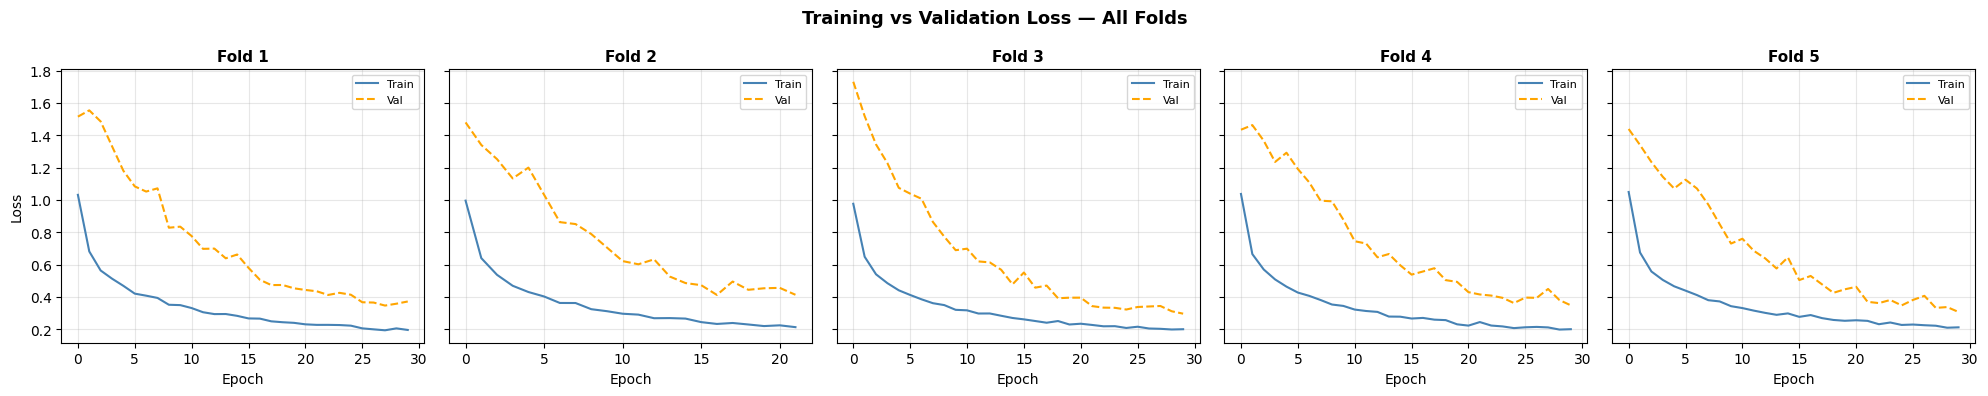

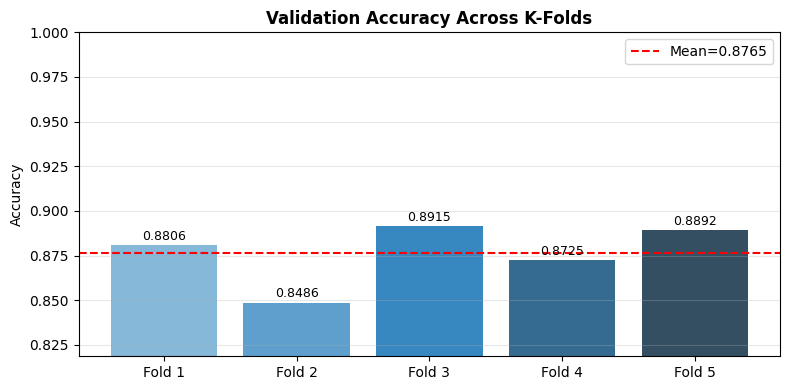

In [55]:
# Plot loss curves for each fold.
# Similar fold curves mean the model behaves consistently across different splits.
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, hist in enumerate(histories):
    axes[i].plot(hist.history['loss'],     label='Train', color='steelblue')
    axes[i].plot(hist.history['val_loss'], label='Val',   color='orange', linestyle='--')
    axes[i].set_title(f'Fold {i+1}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Epoch'); axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)
    if i == 0: axes[i].set_ylabel('Loss')
plt.suptitle('Training vs Validation Loss — All Folds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kfold_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Fold accuracy bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores,
              color=sns.color_palette('Blues_d', 5))
ax.axhline(np.mean(cv_scores), color='red', linestyle='--',
           label=f'Mean={np.mean(cv_scores):.4f}')
for bar, v in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{v:.4f}', ha='center', fontsize=9)
ax.set_title('Validation Accuracy Across K-Folds', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(max(0, min(cv_scores)-0.03), 1.0)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fold_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
# Train the final model.
# After tuning and cross-validation, I train on the full training set using the best settings.
# ModelCheckpoint saves the best version as ANN-model.keras.
es_final = EarlyStopping(monitor='val_loss', patience=7,
                          restore_best_weights=True, verbose=1)
mc_final = ModelCheckpoint('ANN-model.keras', monitor='val_loss',
                            save_best_only=True, verbose=1)

final_model = build_model(dropout=best_config['dropout'], lr=best_config['lr'])
final_model.summary()

final_history = final_model.fit(
    X_train_s, y_train_s,
    epochs=50,
    batch_size=best_config['batch_size'],
    validation_split=0.1,       # small holdout for EarlyStopping monitoring only
    callbacks=[es_final, mc_final],
    class_weight=class_weight_dict,
    verbose=1
)

print('\nFinal model training complete.')
print('Saved: ANN-model.keras')

Model: "ECG_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 89, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 89, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 42, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 42, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       344,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 376,837 (1.44 MB)

 Trainable params: 376,389 (1.44 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5034 - loss: 1.3828
Epoch 1: val_loss improved from None to 1.66426, saving model to ANN-model.keras

Epoch 1: finished saving model to ANN-model.keras
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.5621 - loss: 1.0176 - val_accuracy: 0.4242 - val_loss: 1.6643
Epoch 2/50
2461/2463 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6766 - loss: 0.6828
Epoch 2: val_loss improved from 1.66426 to 1.56284, saving model to ANN-model.keras

Epoch 2: finished saving model to ANN-model.keras
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6934 - loss: 0.6324 - val_accuracy: 0.4899 - val_loss: 1.5628
Epoch 3/50
2454/2463 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7359 - loss: 0.5624
Epoch 3: val_loss improved from 1.56284 to 1.30140, saving model to ANN-model.keras

Epoch 3: finished saving model to ANN-model.keras
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7446 - loss: 0.5383 - val_accuracy: 

In [57]:
#Load the final saved model and generate predictions.
from tensorflow.keras.models import load_model

final_model = load_model('ANN-model.keras')

y_train_pred = np.argmax(final_model.predict(X_train_cnn, verbose=0), axis=1)
y_train_true = np.argmax(y_train_encoded, axis=1)

y_test_pred  = np.argmax(final_model.predict(X_test_cnn,  verbose=0), axis=1)
y_test_true  = np.argmax(y_test_encoded,  axis=1)

print('Predictions generated.')

Predictions generated.


In [58]:
# Print classification reports for train and test.
#This is a better way for comments..
# This gives precision, recall, F1-score, and accuracy for each class.
print('TRAIN SET')
print("\n")
print(classification_report(y_train_true, y_train_pred, target_names=class_names))

print('TEST SET')
print("\n")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

train_acc = accuracy_score(y_train_true, y_train_pred)
test_acc  = accuracy_score(y_test_true,  y_test_pred)
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test  Accuracy: {test_acc:.4f}')
print(f'Gap:            {train_acc - test_acc:.4f}')



TRAIN SET


                precision    recall  f1-score   support

        Normal       1.00      0.87      0.93     72471
Hypersensitive       0.29      0.97      0.44      2223
        Type 1       0.85      0.96      0.90      5788
        Type 2       0.16      0.98      0.28       641
        Type 3       0.96      0.99      0.98      6431

      accuracy                           0.89     87554
     macro avg       0.65      0.95      0.71     87554
  weighted avg       0.96      0.89      0.91     87554

TEST SET


                precision    recall  f1-score   support

        Normal       1.00      0.86      0.92     18118
Hypersensitive       0.25      0.88      0.39       556
        Type 1       0.85      0.94      0.89      1448
        Type 2       0.16      0.93      0.27       162
        Type 3       0.96      0.98      0.97      1608

      accuracy                           0.88     21892
     macro avg       0.64      0.92      0.69     21892
  weighted avg      

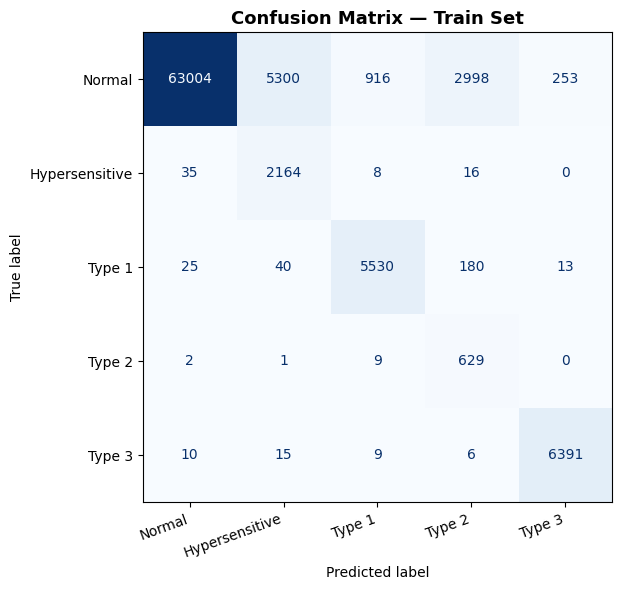


Per-Class Metrics — Train Set:
                   Class  Precision  Recall  Sensitivity  Specificity
        Class 0 — Normal     0.9989  0.8694       0.8694       0.9952
Class 1 — Hypersensitive     0.2878  0.9735       0.9735       0.9372
        Class 2 — Type 1     0.8544  0.9554       0.9554       0.9885
        Class 3 — Type 2     0.1643  0.9813       0.9813       0.9632
        Class 4 — Type 3     0.9600  0.9938       0.9938       0.9967


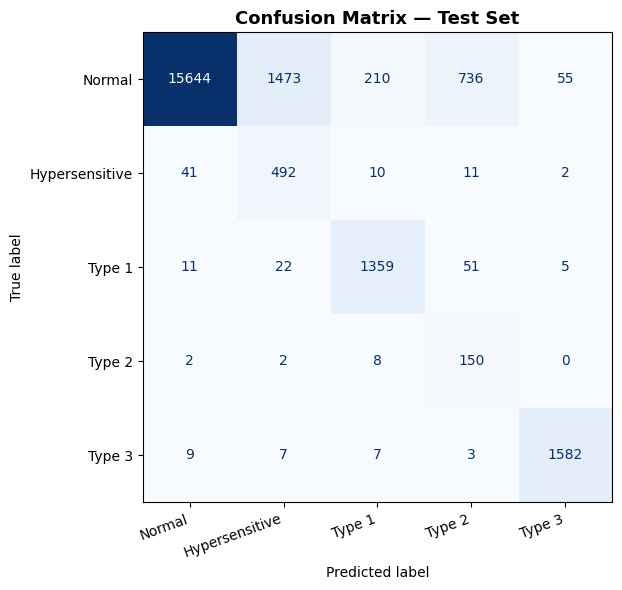


Per-Class Metrics — Test Set:
                   Class  Precision  Recall  Sensitivity  Specificity
        Class 0 — Normal     0.9960  0.8635       0.8635       0.9833
Class 1 — Hypersensitive     0.2465  0.8849       0.8849       0.9295
        Class 2 — Type 1     0.8526  0.9385       0.9385       0.9885
        Class 3 — Type 2     0.1577  0.9259       0.9259       0.9631
        Class 4 — Type 3     0.9623  0.9838       0.9838       0.9969


In [59]:
# Confusion matrices and per-class sensitivity/specificity.
# Sensitivity is recall. Specificity checks how well the model identifies true negatives.
def full_evaluation(y_true, y_pred, dataset_label):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=class_names,
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'Confusion Matrix — {dataset_label}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=20, ha='right'); plt.tight_layout()
    plt.savefig(f'confusion_matrix_{dataset_label.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    mcm  = multilabel_confusion_matrix(y_true, y_pred)
    rows = []
    for i, cm in enumerate(mcm):
        TN, FP, FN, TP = cm.ravel()
        precision   = TP/(TP+FP) if (TP+FP)>0 else 0.0
        sensitivity = TP/(TP+FN) if (TP+FN)>0 else 0.0
        specificity = TN/(TN+FP) if (TN+FP)>0 else 0.0
        rows.append({'Class': f'Class {i} — {class_names[i]}',
                     'Precision': round(precision,4), 'Recall': round(sensitivity,4),
                     'Sensitivity': round(sensitivity,4), 'Specificity': round(specificity,4)})
    df = pd.DataFrame(rows)
    print(f'\nPer-Class Metrics — {dataset_label}:')
    print(df.to_string(index=False))
    return df

train_metrics = full_evaluation(y_train_true, y_train_pred, 'Train Set')
test_metrics  = full_evaluation(y_test_true,  y_test_pred,  'Test Set')



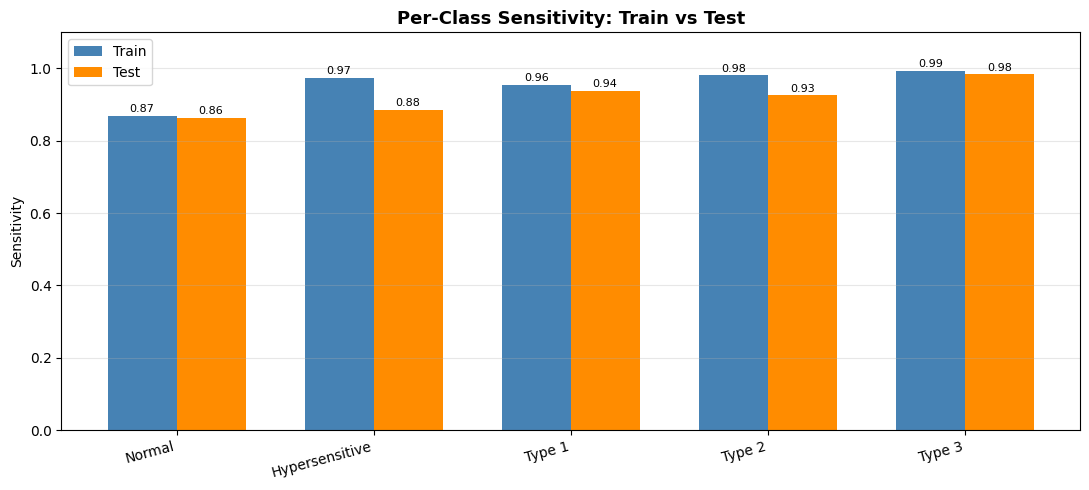

Train Accuracy: 0.8877
Test  Accuracy: 0.8783
Gap:            0.0094


In [60]:
# Bias-variance comparison.
# Comparing train and test sensitivity helps check whether the model is overfitting.
x, width = np.arange(len(class_names)), 0.35
fig, ax  = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x-width/2, train_metrics['Sensitivity'].values, width, label='Train', color='steelblue')
b2 = ax.bar(x+width/2, test_metrics['Sensitivity'].values,  width, label='Test',  color='darkorange')
ax.set_title('Per-Class Sensitivity: Train vs Test', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_ylabel('Sensitivity'); ax.set_ylim(0, 1.1)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('sensitivity_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

gap = train_acc - test_acc
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test  Accuracy: {test_acc:.4f}')
print(f'Gap:            {gap:.4f}')



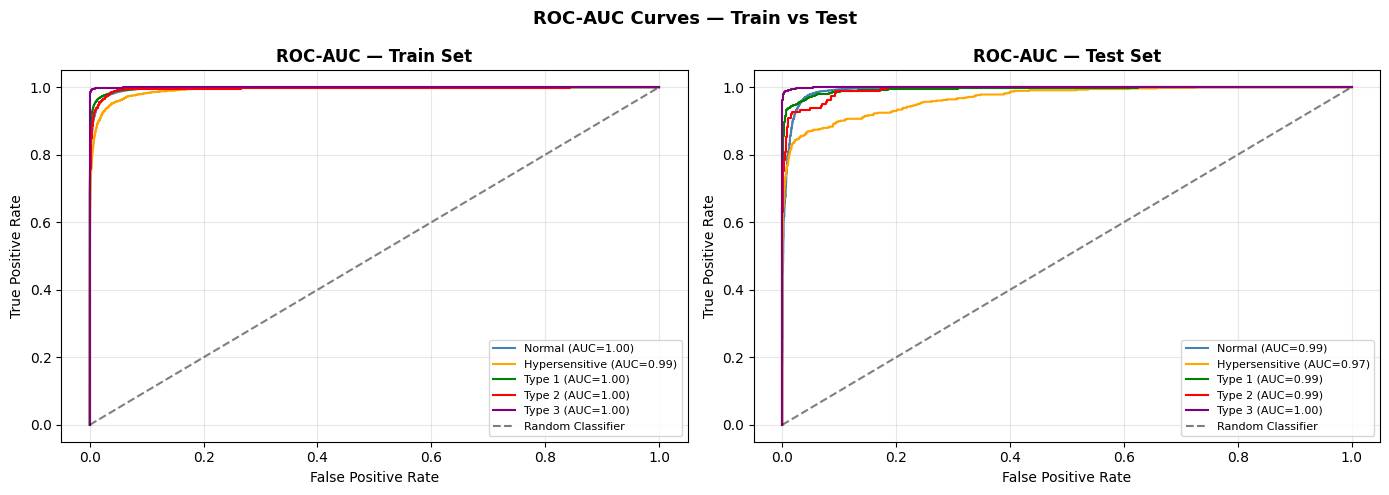

Train Macro ROC-AUC: 0.9963
Test  Macro ROC-AUC: 0.9890


In [61]:
# ROC-AUC curves.
# These show how well the model separates each class from the others.
y_train_probs = final_model.predict(X_train_cnn, verbose=0)
y_test_probs  = final_model.predict(X_test_cnn,  verbose=0)
y_train_bin   = label_binarize(y_train_true, classes=[0,1,2,3,4])
y_test_bin    = label_binarize(y_test_true,  classes=[0,1,2,3,4])
colors        = ['steelblue','orange','green','red','purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_train_bin[:,i], y_train_probs[:,i])
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr,tpr):.2f})')
    fpr, tpr, _ = roc_curve(y_test_bin[:,i],  y_test_probs[:,i])
    axes[1].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

for ax, title in zip(axes, ['ROC-AUC — Train Set', 'ROC-AUC — Test Set']):
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Random Classifier')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('ROC-AUC Curves — Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

train_auc = roc_auc_score(y_train_true, y_train_probs, multi_class='ovr', average='macro')
test_auc  = roc_auc_score(y_test_true,  y_test_probs,  multi_class='ovr', average='macro')
print(f'Train Macro ROC-AUC: {train_auc:.4f}')
print(f'Test  Macro ROC-AUC: {test_auc:.4f}')


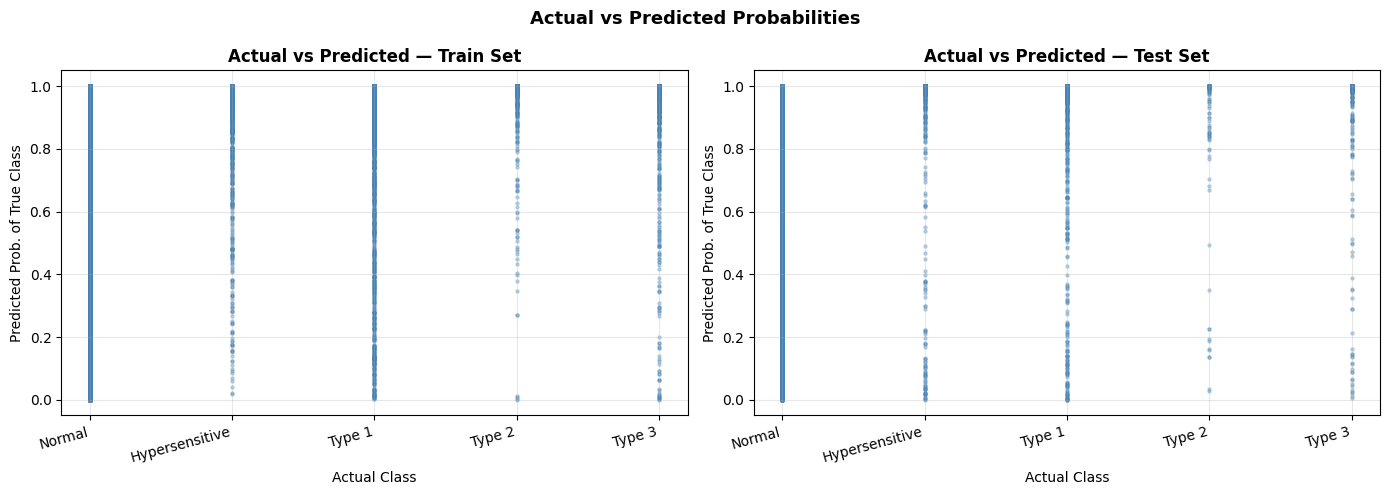

In [62]:
# Actual vs predicted probability plot.
# This checks how confident the model is for the true class on train and test data.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, probs, true, title in zip(
    axes,
    [y_train_probs, y_test_probs],
    [y_train_true,  y_test_true],
    ['Train Set',   'Test Set']
):
    prob_true = probs[np.arange(len(true)), true]
    ax.scatter(true, prob_true, alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel('Actual Class'); ax.set_ylabel('Predicted Prob. of True Class')
    ax.set_title(f'Actual vs Predicted — {title}', fontsize=12, fontweight='bold')
    ax.set_xticks([0,1,2,3,4]); ax.set_xticklabels(class_names, rotation=15, ha='right')
    ax.grid(True, alpha=0.3)
plt.suptitle('Actual vs Predicted Probabilities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()



In [63]:
# Final submission check.
# Reload the saved ANN-model.keras file and print the key final results.
final_model = load_model('ANN-model.keras')

print('SUBMISSION SUMMARY')
print(f'Architecture    : 1D CNN (3 Conv blocks + 2 Dense layers)')
print(f'Parameters      : {final_model.count_params():,}')
print(f'K-Fold Mean Acc : {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
print(f'Train Accuracy  : {train_acc:.4f}')
print(f'Test  Accuracy  : {test_acc:.4f}')
print(f'Test  ROC-AUC   : {test_auc:.4f}')


SUBMISSION SUMMARY
Architecture    : 1D CNN (3 Conv blocks + 2 Dense layers)
Parameters      : 376,837
K-Fold Mean Acc : 0.8765 ± 0.0155
Train Accuracy  : 0.8877
Test  Accuracy  : 0.8783
Test  ROC-AUC   : 0.9890
